In [20]:
import numpy as np
import matplotlib.pyplot as plt


# Task 21: Manual Convolution

Before using `Conv2D`, implement the convolution operation manually using NumPy.

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.
2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.
3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.
4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.
5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?
- Why does the `vertical_edge` output contain both positive and negative values?

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.


In [13]:
def make_square_image(size=28):
    img = np.zeros((size, size))      # black image: size x size array of zeros

    s = 12                            # side length of the white square
    start = (size - s) // 2           # index where the square begins
                                      # (equal black margin on both sides)

    img[start:start + s, start:start + s] = 1

    return img 

2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.

In [14]:
def conv2d(image, kernel, stride=1, padding=0):
    # step 1: add a frame of zeros around the image (padding=0 -> no change)
    image = np.pad(image, padding)

    # step 2: size of the output
    k = kernel.shape[0]                              # kernel size (e.g. 3)
    out_h = (image.shape[0] - k) // stride + 1       # how many windows fit vertically
    out_w = (image.shape[1] - k) // stride + 1       # how many windows fit horizontally

    # step 3: empty output, we will fill it cell by cell
    result = np.zeros((out_h, out_w))

    # step 4: slide the window over the image
    for i in range(out_h):                           # i = row index of the output
        for j in range(out_w):                       # j = column index of the output
            top = i * stride                         # first row of the window in the image
            left = j * stride                        # first column of the window in the image

            # cut a k x k piece of the image (the current window)
            window = image[top:top + k, left:left + k]

            # multiply window and kernel cell by cell, sum everything into one number
            result[i, j] = np.sum(window * kernel)

    # step 5: return the finished output (feature map)
    return result

In [15]:
img = np.array([[1,1,1,0,0]] * 5)
flt = np.array([[1,0,-1]] * 3)
print(conv2d(img, flt))

[[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]


3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.

In [16]:
filters = {
    # compares left column with right column -> reacts to vertical edges
    "vertical_edge": np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]]),

    # compares top row with bottom row -> reacts to horizontal edges
    # (same as vertical_edge, just transposed)
    "horizontal_edge": np.array([[ 1,  1,  1],
                                 [ 0,  0,  0],
                                 [-1, -1, -1]]),

    # average of 9 neighbours: 9 equal weights of 1/9, sum = 1
    "blur": np.ones((3, 3)) / 9,

    # boosts the centre pixel, subtracts the 4 direct neighbours, sum = 1
    "sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),
}

In [17]:
for name, f in filters.items():
    print(name, f.sum())

vertical_edge 0
horizontal_edge 0
blur 1.0
sharpen 1


4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.

In [22]:
def plot_images(images, titles):
    n = len(images)                                   # how many images to show

    # one row with n slots side by side
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    for ax, img, title in zip(axes, images, titles):  # go through slots, images, titles together
        ax.imshow(img, cmap="gray")                   # draw the 2D array as a grayscale image
        ax.set_title(title)                           # name above the image
        ax.axis("off")                                # hide the axis numbers

    plt.tight_layout()                                # avoid overlapping titles
    plt.show()

5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

In [19]:
img = make_square_image()
flt = filters["vertical_edge"]

for p in (0, 1):                       # padding values
    for s in (1, 2):                   # stride values
        out = conv2d(img, flt, stride=s, padding=p)
        print(f"padding={p}, stride={s} -> shape {out.shape}")

padding=0, stride=1 -> shape (26, 26)
padding=0, stride=2 -> shape (13, 13)
padding=1, stride=1 -> shape (28, 28)
padding=1, stride=2 -> shape (14, 14)


(28 + 0(2*padding) -3(filtr)) //1(stride) + 1 = 26

(28 + 0(2*padding) -3(filtr)) //2(stride) + 1 = 13

(28 + 2(2*padding) -3(filtr)) //1(stride) + 1 = 28

(28 + 2(2*padding) -3(filtr)) //2(stride) + 1 = 14

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?

1. The output size is (n + 2p − k) // s + 1, where n is the input size, p is the padding, k is the kernel size and s is the stride. We add the padding to both sides of the input (hence 2p), subtract the kernel size (because the window has to fit inside the image), divide by the stride and round down, and then add 1 (for the first window position).

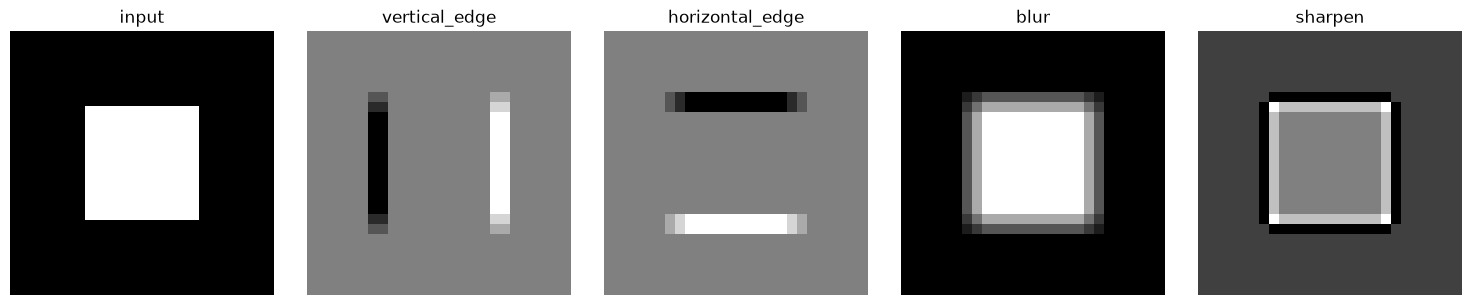

In [23]:
2. 
img = make_square_image()

images = [img]
titles = ["input"]
for name, f in filters.items():
    images.append(conv2d(img, f))
    titles.append(name)

plot_images(images, titles)